In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.datasets import fetch_openml

In [2]:
mnist=fetch_openml(name="mnist_784")
mnist

{'data':        pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
 0           0       0       0       0       0       0       0       0       0   
 1           0       0       0       0       0       0       0       0       0   
 2           0       0       0       0       0       0       0       0       0   
 3           0       0       0       0       0       0       0       0       0   
 4           0       0       0       0       0       0       0       0       0   
 ...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
 69995       0       0       0       0       0       0       0       0       0   
 69996       0       0       0       0       0       0       0       0       0   
 69997       0       0       0       0       0       0       0       0       0   
 69998       0       0       0       0       0       0       0       0       0   
 69999       0       0       0       0       0       0       0       0       0   
 
      

In [3]:
mnist.data

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
mnist.target.astype(int)

0        5
1        0
2        4
3        1
4        9
        ..
69995    2
69996    3
69997    4
69998    5
69999    6
Name: class, Length: 70000, dtype: int32

In [5]:
type(mnist)

sklearn.utils._bunch.Bunch

In [6]:
X=mnist.data
y=mnist.target.astype(int)

In [7]:
cols=mnist.data.columns
for col in cols:
    if((X[col].unique()).size>1):
        print(col,X[col].unique(),"\n")

pixel13 [  0  10 116] 

pixel14 [  0 216 254] 

pixel15 [  0 216] 

pixel16 [0 9] 

pixel33 [ 0 16] 

pixel34 [ 0  8 47 38] 

pixel35 [  0 157  85 114  67 132   2 236] 

pixel36 [  0 102  82 197 253 163 254 212  37  51  30   3  13  47 158] 

pixel37 [  0  93 254 139  35 227  25  22 255 253  34  13  52 111  76 146 133 252
 249 170 233] 

pixel38 [  0 218 253  84   7 254 135  25  55  57  62 226 235  26  64 179 243  31
 128   4 161 113  92  13 132  49  39 133 170 198   2 230  52 144  37 106] 

pixel39 [  0  20 120 147  82  49 158 173  34 145 254  44  10 255 210 163  57 237
 106 116 179  55 208 253  24  32 227 113 231   5  52 201 133 128   3 224
  28 218   4 192  22  21  15] 

pixel40 [  0 124 253 208 240 228  89 130  77 220 128  34 113 185   1 225  93  20
 247 123   9  59  80  35  29 171 195 183 244 190  46 255 212   4 168 215
  79  42 191 199 203 114 193 152  60  70 254  47 169 234 110 186 167 170
  83 108  22  32  28  21  16 162 243 214  41 232  43] 

pixel41 [  0  90  41 103 220 234  2

In [8]:
# values range from 0-255
X=X/255.0

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train,"\n")

       pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
47339     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
67456     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
12308     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
32557     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
664       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
...       ...     ...     ...     ...     ...     ...     ...     ...     ...   
37194     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
6265      0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
54886     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
860       0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
15795     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

       pixel10  ...  pixel7

In [10]:
# X_train.iloc[0]
# X_train.iloc[0].values
# X_train.iloc[0].values.size
# X_train.iloc[0].values.reshape(49,16)
X_test.iloc[0].values.reshape(28,28)

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

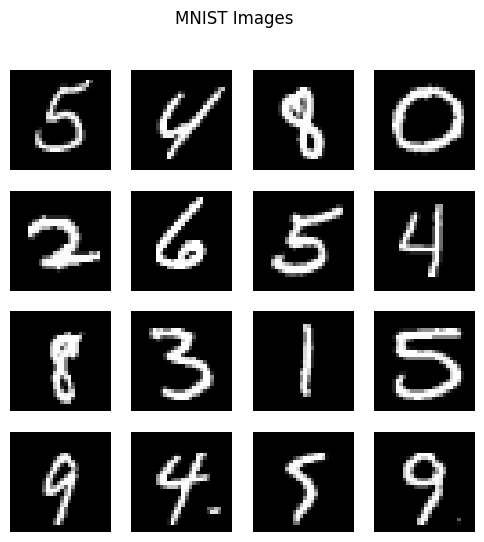

In [11]:
plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train.iloc[i].values.reshape(28,28),cmap="gray")
    plt.axis("off")
plt.suptitle("MNIST Images")
plt.show()    

In [12]:
X_train=X_train.to_numpy()
X_test=X_test.to_numpy()
y_test=y_test.to_numpy()
y_train=y_train.to_numpy()

In [13]:
svm1=SVC(kernel="linear")
svm2=SVC(kernel="poly")
svm3=SVC(kernel="precomputed")
svm4=SVC(kernel="rbf")
svm5=SVC(kernel="sigmoid")

In [ ]:
# svms=[svm1,svm2,svm3,svm4,svm5]
# for i in range(6):
#     svms[i].fit(X_train,y_train)
#     y_pred=svms[i].predict(X_test)
#     print(f"Accuracy of {svms[i]} : {accuracy_score(y_test,y_pred)}")

# ^ high computational cost
# use linearSVC instead


In [16]:
from sklearn.svm import LinearSVC

In [18]:
svm_linear=LinearSVC(verbose=1,max_iter=3000)
svm_linear.fit(X_train,y_train)
y_pred_linear=svm_linear.predict(X_test)

[LibLinear]

In [19]:
print(f"Accuracy of LinearSVM = {accuracy_score(y_test,y_pred_linear)}")

Accuracy of LinearSVM = 0.9147857142857143


In [ ]:
from skimage.feature import hog

In [26]:
def extract_hog_features(images):
    hog_features = []
    for img in images:
        img = img.reshape(28,28)
        features = hog(img,orientations=9,pixels_per_cell=(8,8),cells_per_block=(2,2),block_norm='L2-Hys')
        hog_features.append(features)
    return np.array(hog_features)

In [27]:
X_train_hog = extract_hog_features(X_train)
X_test_hog = extract_hog_features(X_test)
print(f"HOG Feature Shape = {X_train_hog.shape}")

HOG Feature Shape = (56000, 144)


In [ ]:
svm_hog=SVC(kernel="linear")
svm_hog.fit(X_train_hog,y_train)
y_pred_hog=svm_hog.predict(X_test_hog)
print(f"Accuracy = {accuracy_score(y_test,y_pred_hog)}")

# Accuracy jumped from 0.9147 to 0.9537

Accuracy = 0.9537857142857142
